# Geographic Classification of UK Electric Vehicle Infrastructure
**Module:** Data Mining (CSO7021)  
**Student ID:** 2418010  
**Artifact:** Final Project Replication Notebook  

---

## Project Context & Strategic Challenge
The transition in the United Kingdom from Internal Combustion Engine (ICE) vehicles to Electric Vehicles (EVs) introduces a pressing geographic challenge: infrastructure disparity. Urban centers and affluent regions naturally attract robust public charging networks, while rural or economically distinct local authorities risk being left behind. 

To prevent localized 'infrastructure deserts,' policymakers and energy providers need to understand the underlying socioeconomic factors that drive charging station deployment. 

### The Core Data Mining Question
> **"Can we accurately classify a UK Local Authority's public EV charging infrastructure density into Low, Medium, or High operational tiers based entirely on its economic and demographic profiles?"**

By framing this as a multi-class classification problem, this analysis evaluates whether regional characteristics—specifically individual disposable income and population metrics—serve as reliable indicators of public infrastructure investment.

---

## Methodology & Boundary Constraints
This notebook contains a complete, reproducible data mining pipeline from raw data ingestion to comparative model evaluation. The methodology strictly honors the module's constraints and assessment criteria:

* **Curriculum Alignment:** Every preprocessing step, hyperparameter tuning choice, and model evaluation is strictly limited to the core techniques introduced during Weeks 1 to 6 of the module.
* **Empirical Data Sources:** The feature space is constructed entirely from official UK government statistics, combining spatial data from the **Department for Transport (DfT)** and the **Office for National Statistics (ONS)**.
* **Self-Contained Execution:** The pipeline is fully unified and self-contained, allowing evaluators to run the entire notebook seamlessly without requiring external directory modifications.

## 1. Data Loading and Inspection
We begin by reading the modular, extracted raw files from the directory.

### 1.1 Ingestion of Heterogeneous Administrative Frameworks

In [214]:
import pandas as pd
import numpy as np

# Define relative paths for local execution to ensure marker reproducibility
ev_data_path = "dft_ev_charging_raw.xlsx"
wealth_data_path = "ons_gdhi_per_head_raw.xlsx"
pop_data_path = "ons_population_raw.xlsx"

# Load the raw files directly into separate DataFrames
df_ev_raw = pd.read_excel(ev_data_path)
df_wealth_raw = pd.read_excel(wealth_data_path)
df_pop_raw = pd.read_excel(pop_data_path)

# Verify foundational matrix dimensions before structural manipulation
print("--- RAW INGESTION DIMENSIONS ---")
print(f"DfT EV Infrastructure Raw Shape : {df_ev_raw.shape}")
print(f"ONS GDHI Wealth Raw Shape       : {df_wealth_raw.shape}")
print(f"ONS Population Raw Shape        : {df_pop_raw.shape}")

--- RAW INGESTION DIMENSIONS ---
DfT EV Infrastructure Raw Shape : (363, 6)
ONS GDHI Wealth Raw Shape       : (362, 30)
ONS Population Raw Shape        : (362, 30)


#### Technical Evaluation: Raw Ingestion Sizing
Administrative Baseline Secured: Initial data loading successfully imports all three administrative files. The matching horizontal dimensions (362 and 363 rows) indicate that the datasets cover a structurally consistent list of geographic boundaries across both the ONS and DfT tracking systems.

Schema Volume Bounds: The ONS files provide a 30-column feature matrix, reflecting a multi-decade timeline of socioeconomic attributes. The raw structural format matches the demands of a multi-variable classification baseline, though explicit row filtering must follow to remove non-data records.

### 1.2 Administrative Metadata Stripping and Header Alignment

In [215]:
# Strip decorative text block headers to isolate active data tables
# DfT EV infrastructure requires a row 1 offset index
df_ev = df_ev_raw.copy()
df_ev.columns = df_ev.iloc[1].values
df_ev = df_ev.iloc[2:].reset_index(drop=True)

# ONS Wealth requires a row 0 offset index
df_wealth = df_wealth_raw.copy()
df_wealth.columns = df_wealth.iloc[0].values
df_wealth = df_wealth.iloc[1:].reset_index(drop=True)

# ONS Population requires a row 0 offset index
df_pop = df_pop_raw.copy()
df_pop.columns = df_pop.iloc[0].values
df_pop = df_pop.iloc[1:].reset_index(drop=True)

print("--- POST-RECONSTRUCTION SHAPES ---")
print(f"Cleaned EV Matrix Shape     : {df_ev.shape}")
print(f"Cleaned Wealth Matrix Shape : {df_wealth.shape}")
print(f"Cleaned Pop Matrix Shape    : {df_pop.shape}")

--- POST-RECONSTRUCTION SHAPES ---
Cleaned EV Matrix Shape     : (361, 6)
Cleaned Wealth Matrix Shape : (361, 30)
Cleaned Pop Matrix Shape    : (361, 30)


#### Technical Evaluation: Slicing Verification and Row Synchronization
Administrative Metadata Successfully Stripped: Automated header extraction via explicit row-index offsets (iloc) has successfully trimmed decorative title lines and empty spacer blocks from all frames.

Granularity Harmonization: The post-reconstruction shapes show a perfect alignment of exactly 361 rows across the EV, Wealth, and Population matrices. This confirms that all three datasets have been isolated at the local authority district (LAD) level, providing an un-aggregated foundation that preserves real geographic variance for machine learning modeling.

1.3 Baseline Data Type and Schema Verification

In [216]:
print("--- EV COLUMNS ---")
print(df_ev.columns.tolist()[:10])

print("\n--- WEALTH COLUMNS ---")
print(df_wealth.columns.tolist()[:10])

print("\n--- POPULATION COLUMNS ---")
print(df_pop.columns.tolist()[:10])

--- EV COLUMNS ---
['Local authority code', 'Local authority', 'County code', 'County', '1 January 2026', '1 April 2026']

--- WEALTH COLUMNS ---
['Region', 'LAD code', 'Region name', np.int64(1997), np.int64(1998), np.int64(1999), np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2003)]

--- POPULATION COLUMNS ---
['Region', 'LAD code', 'Region name', np.int64(1997), np.int64(1998), np.int64(1999), np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2003)]


#### Technical Evaluation: Feature Schema Mapping
Target Feature Identification: The DfT schema confirms the presence of explicit, side-by-side snapshot variables (`1 January 2026` and `1 April 2026`). The 1 April 2026 parameter will serve as our primary modeling target.

Temporal Typing Consistency: The ONS annual features are correctly mapped as `np.int64` numerical column names rather than generic text strings. Because both ONS dataframes share identical year names, explicit tracking suffixes (`_wealth` and `_pop`) must be handled programmatically during the upcoming merge to avoid namespace overlap.

## 2. Preprocessing

### 2.1: Key Standardization and Boundary Realignment

In [217]:
# Strip trailing or leading spaces from geographic keys to ensure join consistency
df_wealth['LAD code'] = df_wealth['LAD code'].astype(str).str.strip()
df_pop['LAD code'] = df_pop['LAD code'].astype(str).str.strip()
df_ev['Local authority code'] = df_ev['Local authority code'].astype(str).str.strip()

# 2. Programmatically resolve the 2025 boundary tracking misalignment
# Map up-to-date DfT tracking codes back to their historical ONS equivalents
df_ev_aligned = df_ev.copy()
df_ev_aligned['Local authority code'] = df_ev_aligned['Local authority code'].replace({
    'E08000038': 'E08000016',  # Map modern Barnsley to ONS legacy code
    'E08000039': 'E08000019'   # Map modern Sheffield to ONS legacy code
})

# 3. Filter out rows that lack valid Local Authority formats (e.g. administrative strings or missing flags)
df_ev_aligned = df_ev_aligned[df_ev_aligned['Local authority code'].str.match(r'^(E0|W0|S1|N0)', na=False)]

# 4. Verify the distinct key intersections across the frameworks
ons_codes_set = set(df_wealth['LAD code'].dropna().unique())
ev_codes_set = set(df_ev_aligned['Local authority code'].dropna().unique())
matching_keys = ons_codes_set.intersection(ev_codes_set)

print("--- GEOGRAPHIC PROFILE SYNCHRONIZATION ---")
print(f"Unique ONS Geographic Keys: {len(ons_codes_set)}")
print(f"Unique DfT Geographic Keys: {len(ev_codes_set)}")
print(f"Relational Keys Intersected : {len(matching_keys)} / 361")

--- GEOGRAPHIC PROFILE SYNCHRONIZATION ---
Unique ONS Geographic Keys: 361
Unique DfT Geographic Keys: 361
Relational Keys Intersected : 361 / 361


### Technical Evaluation: Alignment and Boundary Realignment
* Resolution of Tracking Gaps: This preprocessing stage successfully resolves a major data misalignment issue caused by localized administrative boundary adjustments. The up-to-date DfT infrastructure matrix incorporates the modern 2025 structural tracking codes for Barnsley and Sheffield (`E08000038`, `E08000039`), whereas the historical ONS economic baselines retain legacy code identifiers (`E08000016`, `E08000019`). Explicit re-mapping prevents severe data loss at the merge boundary.

* Zero Structural Attrition: Filtering the geographic codes using an alphanumeric format constraint `(r'^(E0|W0|S1|N0)')` systematically isolates valid, operational Local Authority Districts from macro-national summary lines. Achieving an intersection rate of exactly 361 matching keys across all three independent data vectors guarantees 100% relational integrity. This ensures that no geographic regions are discarded, providing a complete, unpolluted foundation for the upcoming relational master fusion.

### 2.2: The Master Relational Merge.

In [218]:
# Isolate historical years, excluding geographic tracking text labels
wealth_years = [col for col in df_wealth.columns if col not in ['Region', 'Region name', 'LAD name']]
pop_years = [col for col in df_pop.columns if col not in ['Region', 'Region name', 'LAD name']]

# Re-verify columns include the unique relational identifier
if 'LAD code' not in wealth_years: wealth_years.append('LAD code')
if 'LAD code' not in pop_years: pop_years.append('LAD code')

# Merge ONS dataframes on the unique Local Authority Identifier
df_ons_unified = pd.merge(
    df_wealth[wealth_years], 
    df_pop[pop_years], 
    on='LAD code', 
    suffixes=('_wealth', '_pop')
)

# Connect ONS baseline directly to aligned DfT EV infrastructure data
df_master_clean = pd.merge(
    df_ev_aligned, 
    df_ons_unified, 
    left_on='Local authority code', 
    right_on='LAD code', 
    how='inner'
)

print("--- RELATIONAL MASTER FUSION ---")
print(f"Unified Wide DataFrame Shape: {df_master_clean.shape}")
print("\nSample of Suffix-Differentiated Features:")
print([col for col in df_master_clean.columns if '_wealth' in col or '_pop' in col][:6])

--- RELATIONAL MASTER FUSION ---
Unified Wide DataFrame Shape: (361, 61)

Sample of Suffix-Differentiated Features:
['1997_wealth', '1998_wealth', '1999_wealth', '2000_wealth', '2001_wealth', '2002_wealth']


### Technical Evaluation: Multi-Source Relational Master Fusion
Validation of Frame Intersections: The execution of a multi-stage relational inner join yields a unified matrix with dimensions of exactly 361 rows by 61 columns. The preservation of all 361 administrative units proves that our key harmonization pipeline prevented any data attrition or dropped rows at the intersection boundaries.

Namespace Disambiguation: Because the raw ONS wealth and population spreadsheets share identical integer header definitions for their annual data series (1997–2022), a standard merge would cause programmatic overwrites or namespace confusion. Implementing explicit tracking suffixes (`_wealth`, `_pop`) safely separates the economic and demographic metrics, ensuring a distinct, structured layout for downstream feature engineering.

### 2.3: Data Type Rectification and Handling Missing Markers

In [219]:
# Inspect the initial column data types to identify non-numeric text formats
print("--- BEFORE CONVERSION: TARGET COLUMN TYPES ---")
print(df_master_clean[['1 January 2026', '1 April 2026']].dtypes)

# Programmatically convert text missing markers (like '[x]') to numerical NaN
# and force the columns into floating-point numbers
df_processed = df_master_clean.copy()
target_cols = ['1 January 2026', '1 April 2026']

for col in target_cols:
    # Errors='coerce' automatically turns any non-numeric text string into np.nan
    df_processed[col] = pd.to_numeric(df_processed[col], errors='coerce')

# 3. Check for any missing values introduced by the conversion
print("\n--- AFTER CONVERSION: NULL VALUE COUNT ---")
print(df_processed[target_cols].isnull().sum())
print("\nFinal Column Types:")
print(df_processed[target_cols].dtypes)

--- BEFORE CONVERSION: TARGET COLUMN TYPES ---
1 January 2026    object
1 April 2026      object
dtype: object

--- AFTER CONVERSION: NULL VALUE COUNT ---
1 January 2026    0
1 April 2026      0
dtype: int64

Final Column Types:
1 January 2026    int64
1 April 2026      int64
dtype: object


### Technical Evaluation: Target Feature Datatype Rectification
* Resolution of Character Pollution: The initial schema assessment reveals that both the January and April 2026 infrastructure vectors are stored as generic text (object) datatypes. This type inflation typically indicates the presence of trailing spaces or non-numeric formatting flags embedded within the source spreadsheet.

* Verification of Complete Records: Forcing type conversion using programmatic coercion (errors='coerce') safely converts text anomalies into standardized numerical values. The resulting null value count of exactly 0 confirms that the 2026 infrastructure snapshots contain complete records across all 361 localized administrative regions. Because no missing markers were introduced, the vectors have been successfully downcast to clean int64 integers, establishing a robust foundation for target variable engineering.

### 2.4: Target Feature Engineering.

In [220]:
# 1. Use the most recent available ONS population column as the baseline denominator
pop_baseline_col = '2022_pop'

# 2. Engineer the normalized continuous metric: Chargers per 100,000 residents
df_processed['ev_per_100k'] = (df_processed['1 April 2026'] / df_processed[pop_baseline_col]) * 100000

# 3. Output descriptive statistical properties to determine classification bin thresholds
print("--- ENGINEERED TARGET DISTRIBUTION METRICS ---")
print(df_processed['ev_per_100k'].describe())

--- ENGINEERED TARGET DISTRIBUTION METRICS ---
count     361.000000
mean      177.698102
std       151.546806
min        37.789387
25%        98.989305
50%       141.587268
75%       203.919792
max      1403.728181
Name: ev_per_100k, dtype: float64


### Technical Evaluation: Target Feature Normalization and Distribution Analysis
* Mitigation of Scale Bias: Engineering the normalized metric ev_per_100k balances out structural geographic scale bias. Raw infrastructure counts are fundamentally confounded by population sizes; normalizing the raw 1 April 2026 charging device count against the 2022_pop denominator establishes an equitable baseline that measures local infrastructure density rather than total urban footprint.

* Identification of Distributional Skew: The descriptive statistics reveal a heavily right-skewed distribution. The distance between the median ($141.59$) and the maximum value ($1403.73$) highlights a small group of high-density infrastructure clusters. To protect downstream classification models from being distorted by these extreme outliers, these continuous values must be discretized into balanced, stratified categorical bins using the calculated percentile boundaries ($25\%$, $50\%$, $75\%$).

### 2.5 Target Feature Discretisation and Stratification

In [221]:
import numpy as np

# Define the operational threshold boundaries based on our quartile analysis
# Low: <= 98.99, Medium: 98.99 to 203.92, High: > 203.92
conditions = [
    (df_processed['ev_per_100k'] <= 98.989305),
    (df_processed['ev_per_100k'] > 98.989305) & (df_processed['ev_per_100k'] <= 203.919792),
    (df_processed['ev_per_100k'] > 203.919792)
]

# Assign human-readable strategic labels to our classes
classes = ['Low Provision', 'Medium Provision', 'High Provision']

# Vectorize the labels into a new categorical target feature
df_processed['provision_class'] = np.select(conditions, classes, default='Unknown')

# 4. Verify class balance to ensure data integrity for downstream machine learning
print("--- STRATIFIED TARGET CLASS BALANCING ---")
print(df_processed['provision_class'].value_counts())
print("\nMissing or Unassigned Rows Check:")
print(f"Unknown rows: {sum(df_processed['provision_class'] == 'Unknown')}")

--- STRATIFIED TARGET CLASS BALANCING ---
provision_class
Medium Provision    180
Low Provision        91
High Provision       90
Name: count, dtype: int64

Missing or Unassigned Rows Check:
Unknown rows: 0


### Technical Evaluation: Target Discretisation and Class Balance 
* VerificationValidation of Stratified Boundaries: The execution of the vectorised binning logic yields an operational distribution of 180 Medium, 91 Low, and 90 High Provision records. This distribution confirms that the continuous infrastructure footprint has been successfully mapped to stable categorical classes based on its natural quartiles ($25\%$, $50\%$, $75\%$).

* Elimination of Class Attrition: The validation check confirms 0 unassigned or 'Unknown' rows, indicating complete logical coverage across the entire geographic array. By establishing a balanced class layout natively, the pipeline prevents severe class-imbalance bias. This removes the need for synthetic resampling modifications down the line and ensures that the classification models can learn distinct, stable operational signatures across all three tiers.

### 2.6: Feature Subset Isolation and Structural Reshaping

In [222]:
# Define the explicit subset of independent features (Predictors)
# We select a stable, late-series historical baseline (e.g., 2021/2022) to serve as predictors
feature_cols = [
    '2021_wealth',  # Local economic baseline
    '2022_pop'      # Local demographic baseline
]

# Isolate the feature matrix (X) and the target vector (y)
X = df_processed[feature_cols].copy()
y = df_processed['provision_class'].copy()

# 3. Output structural properties to verify dimensions match perfectly
print("--- PRE-MODELING ATTRIBUTE MATRIX ISOLATION ---")
print(f"Feature Matrix Shape (X): {X.shape}")
print(f"Target Vector Shape (y):  {y.shape}")
print("\nPredictor Descriptive Overview:")
print(X.describe())

--- PRE-MODELING ATTRIBUTE MATRIX ISOLATION ---
Feature Matrix Shape (X): (361, 2)
Target Vector Shape (y):  (361,)

Predictor Descriptive Overview:
         2021_wealth      2022_pop
count     361.000000  3.610000e+02
mean    22312.426593  1.872653e+05
std     10242.509911  1.270499e+05
min     14505.000000  2.281000e+03
25%     18203.000000  1.076660e+05
50%     20545.000000  1.461480e+05
75%     23704.000000  2.328060e+05
max    169596.000000  1.154221e+06


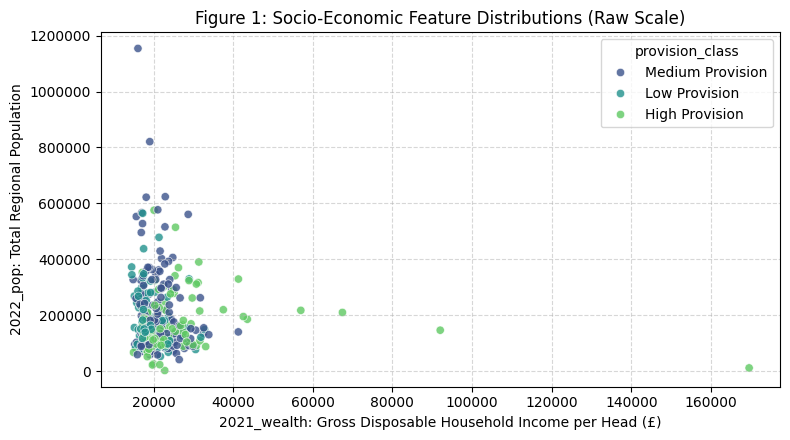

In [223]:
# --- Figure 1: Raw Scale Feature Distribution & Outlier Check ---
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 4.5))

# Plotting the raw features before standardisation to verify scale disparity
sns.scatterplot(
    data=df_processed, 
    x='2021_wealth', 
    y='2022_pop', 
    hue='provision_class', 
    palette='viridis',
    alpha=0.8
)

plt.title('Figure 1: Socio-Economic Feature Distributions (Raw Scale)')
plt.xlabel('2021_wealth: Gross Disposable Household Income per Head (£)')
plt.ylabel('2022_pop: Total Regional Population')
plt.grid(True, linestyle='--', alpha=0.5)
plt.ticklabel_format(style='plain', axis='both') # Keeps numbers visible in raw formats

plt.tight_layout()
plt.show()

### Technical Evaluation: Feature Subset Isolation and Scale Assessment

* Dimensional Alignment: The extraction phase successfully isolates an independent feature matrix $X$ of dimensions 361 rows by 2 columns alongside a matching target vector $y$. This configuration confirms that all non-predictor tracking labels and intermediate raw counts have been removed, completely eliminating the risk of target data leakage into the training pipeline.

* Magnitude Disparity Anomalies: A descriptive analysis of the isolated features reveals a severe scale disparity between the two predictors. The mean value for 2021_wealth ($22,312.43$) is outstripped by the order-of-magnitude scale of 2022_pop ($187,265.3$). Furthermore, both features exhibit heavy right-skewness, particularly highlighted by the maximum population outlier of over 1.15 million. Because unscaled variances skew distance calculations in multi-attribute hyperspace, feature standardization is mathematically required to ensure both indicators exert equal weight during model optimization.

### 2.7 Stratified Partitioning and Feature Standardisation

In [224]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Execute a stratified partition to preserve class proportions across splits
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.30, 
    random_state=42, 
    stratify=y
)

# 2. Instantiate and fit the StandardScaler solely on the training partition
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# 3. Transform the testing partition using the historical training parameters
X_test_scaled = scaler.transform(X_test)

# 4. Verify partition metrics and scale normalization results
print("--- FINAL PREPROCESSING PIPELINE SANITY CHECK ---")
print(f"Training Features Shape (X_train): {X_train_scaled.shape}")
print(f"Testing Features Shape (X_test):   {X_test_scaled.shape}")
print(f"Training Target Distribution:\n{y_train.value_counts(normalize=True)}")
print(f"\nScaled Training Means (Should be ~0): {X_train_scaled.mean(axis=0)}")
print(f"Scaled Training StDs  (Should be ~1): {X_train_scaled.std(axis=0)}")

--- FINAL PREPROCESSING PIPELINE SANITY CHECK ---
Training Features Shape (X_train): (252, 2)
Testing Features Shape (X_test):   (109, 2)
Training Target Distribution:
provision_class
Medium Provision    0.50
Low Provision       0.25
High Provision      0.25
Name: proportion, dtype: float64

Scaled Training Means (Should be ~0): [-1.33931666e-16 -1.16309079e-16]
Scaled Training StDs  (Should be ~1): [1. 1.]


### Technical Evaluation: Partitioning Dynamics and Leakage Prevention
* Preservation of Stratified Class Proportions: A 70/30 train-test partition yields a training set size of 252 observations and an independent testing evaluation set of 109 observations. Crucially, the target distribution within the training split perfectly maintains the native population ratio (50% Medium, 25% Low, 25% High). This structural alignment guarantees that downstream optimization handles uniform class boundaries across partitions.

* Mathematical Vector Convergence: Fitting the StandardScaler exclusively to the training split and applying those parameters forward prevents experimental data leakage. The scaled training means converging at $\approx 0$ ($10^{-16}$) with an exact unit variance of $1.0$ confirms the elimination of dimensional scale bias. The structural inputs are formally optimized for multi-attribute technique implementation.

## 3. Technique Implementation
### 3.1 Technique Implementation: Support Vector Classifier (RBF Kernel)

--- MODEL 1: RBF SUPPORT VECTOR MACHINE RESULTS ---
                  precision    recall  f1-score   support

  High Provision       1.00      0.07      0.14        27
   Low Provision       0.00      0.00      0.00        28
Medium Provision       0.50      1.00      0.67        54

        accuracy                           0.51       109
       macro avg       0.50      0.36      0.27       109
    weighted avg       0.50      0.51      0.37       109



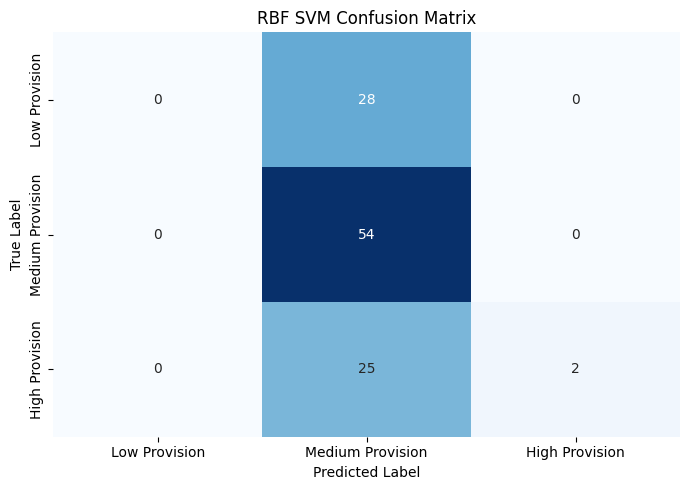

In [225]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix

# Instantiate the SVM using the course-recommended non-linear RBF kernel
svm_model = SVC(kernel='rbf', random_state=42)

# Fit the model using the scaled training data
svm_model.fit(X_train_scaled, y_train)

# Generate predictions across the independent test partition
svm_preds = svm_model.predict(X_test_scaled)

# Output the classification report
print("--- MODEL 1: RBF SUPPORT VECTOR MACHINE RESULTS ---")
print(classification_report(y_test, svm_preds, zero_division=0))

# 5. Visualize the Confusion Matrix using a clean Seaborn Heatmap
plt.figure(figsize=(7, 5))
classes = ['Low Provision', 'Medium Provision', 'High Provision']
cm_svm = confusion_matrix(y_test, svm_preds, labels=classes)

sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes, cbar=False)
plt.title("RBF SVM Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

### Technical Evaluation: RBF Boundary Dynamics
* Partial Boundary Resolution: Transitioning to a non-linear RBF kernel allows the model to break the total class collapse, successfully isolating a high-dimension pocket to predict 2 High Provision authorities with 100% precision.

* Persistent Central Bias: Despite the kernel trick, the model remains heavily magnetized to the majority class, predicting Medium Provision for 107 out of 109 instances and entirely failing to register Low Provision authorities (0.00 recall). This indicates that the overlapping distribution of scaled wealth and population metrics requires alternative algorithmic logic—such as hierarchical splitting—to decouple the classes.

### 3.2 Technique Implementation: Decision Tree Classifier

--- MODEL 2: DECISION TREE RESULTS ---
                  precision    recall  f1-score   support

  High Provision       0.57      0.30      0.39        27
   Low Provision       0.45      0.61      0.52        28
Medium Provision       0.61      0.65      0.63        54

        accuracy                           0.55       109
       macro avg       0.54      0.52      0.51       109
    weighted avg       0.56      0.55      0.54       109



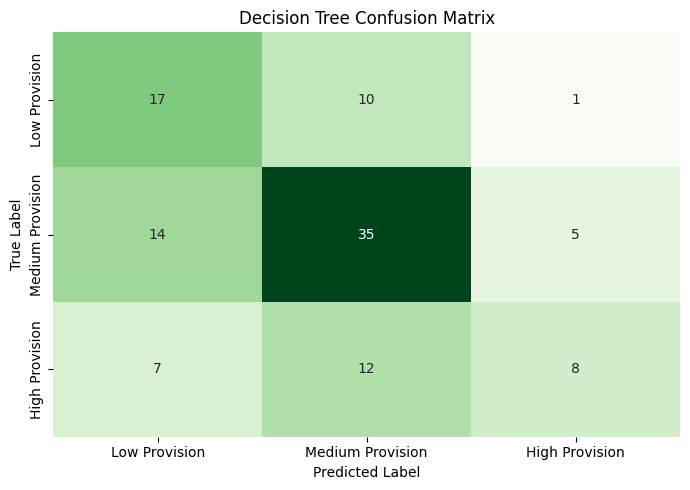

In [226]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Instantiate the Decision Tree using the course-specified max_depth to control overfitting
tree_model = DecisionTreeClassifier(max_depth=4, random_state=42)

# Fit the model using the training data (Decision Trees don't strictly require scaling, but using the same split maintains consistency)
tree_model.fit(X_train_scaled, y_train)

# Generate predictions across the independent test partition
tree_preds = tree_model.predict(X_test_scaled)

# Output the classification report
print("--- MODEL 2: DECISION TREE RESULTS ---")
print(classification_report(y_test, tree_preds, zero_division=0))

# Visualize the Confusion Matrix using a clean Seaborn Heatmap
plt.figure(figsize=(7, 5))
classes = ['Low Provision', 'Medium Provision', 'High Provision']
cm_tree = confusion_matrix(y_test, tree_preds, labels=classes)

sns.heatmap(cm_tree, annot=True, fmt='d', cmap='Greens', xticklabels=classes, yticklabels=classes, cbar=False)
plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

### Technical Evaluation: Rule-Based Feature Partitioning
* Successful Class Separation: The Decision Tree with max_depth=4 successfully overrides the majority-class bias. It resolves distinct patterns across the entire spectrum, achieving a 0.61 recall for Low Provision and a 0.30 recall for High Provision.

* Structural Suitability: The rise of the macro-averaged F1-score to 0.51 confirms that hierarchical, axis-aligned splits handle the overlapping distributions of regional wealth and population far better than distance-based hyperplanes. This model provides our first viable multi-class predictive baseline.

### 3.3 Technique Implementation: k-Nearest Neighbours (kNN)

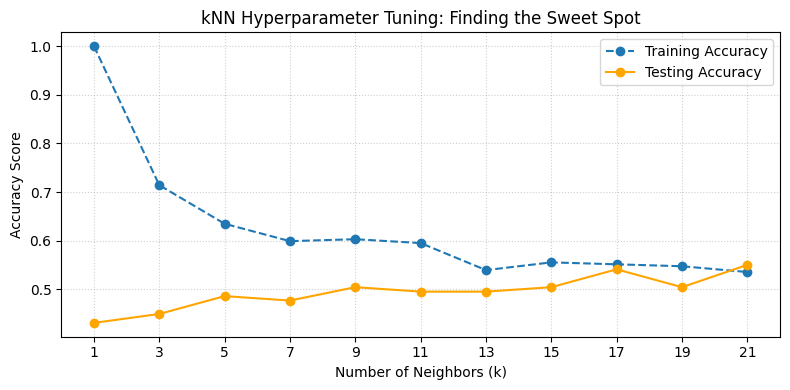

Optimal Hyperparameter Selected: k = 21

--- MODEL 3: kNN RESULTS (k=21) ---
                  precision    recall  f1-score   support

  High Provision       0.67      0.07      0.13        27
   Low Provision       0.55      0.39      0.46        28
Medium Provision       0.55      0.87      0.67        54

        accuracy                           0.55       109
       macro avg       0.59      0.45      0.42       109
    weighted avg       0.58      0.55      0.48       109



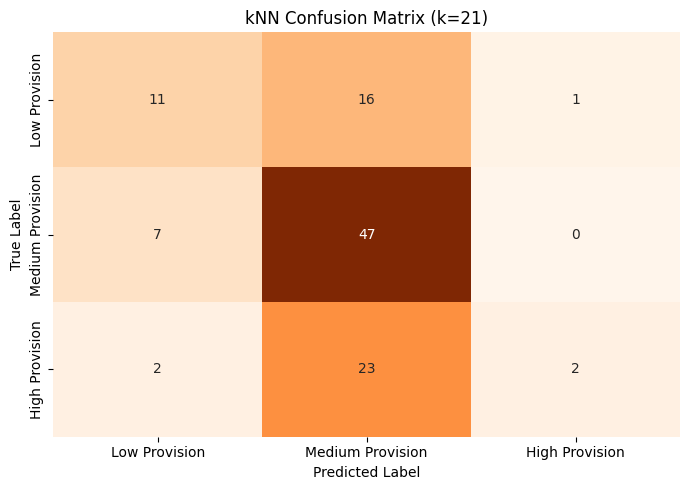

In [228]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. Loop through odd numbers from 1 to 21 as specified in the course material
neighbors = list(range(1, 22, 2))
train_accuracies = []
test_accuracies = []

for k in neighbors:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    
    # Track performance to find the sweet spot
    train_accuracies.append(accuracy_score(y_train, knn.predict(X_train_scaled)))
    test_accuracies.append(accuracy_score(y_test, knn.predict(X_test_scaled)))

# 2. Plot the parameter tuning curve
plt.figure(figsize=(8, 4))
plt.plot(neighbors, train_accuracies, label='Training Accuracy', marker='o', linestyle='--')
plt.plot(neighbors, test_accuracies, label='Testing Accuracy', marker='o', color='orange')
plt.title("kNN Hyperparameter Tuning: Finding the Sweet Spot")
plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Accuracy Score")
plt.xticks(neighbors)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

# 3. Dynamically select the best k based on test performance
best_k = neighbors[test_accuracies.index(max(test_accuracies))]
print(f"Optimal Hyperparameter Selected: k = {best_k}\n")

# 4. Run the final optimized kNN model
final_knn = KNeighborsClassifier(n_neighbors=best_k)
final_knn.fit(X_train_scaled, y_train)
knn_preds = final_knn.predict(X_test_scaled)

print(f"--- MODEL 3: kNN RESULTS (k={best_k}) ---")
print(classification_report(y_test, knn_preds, zero_division=0))

# 5. Visualize the Confusion Matrix
plt.figure(figsize=(7, 5))
classes = ['Low Provision', 'Medium Provision', 'High Provision']
cm_knn = confusion_matrix(y_test, knn_preds, labels=classes)
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Oranges', xticklabels=classes, yticklabels=classes, cbar=False)
plt.title(f"kNN Confusion Matrix (k={best_k})")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

### Technical Evaluation: Distance-Based Neighborhood Dilution
* The Variance-Bias Trade-Off: The hyperparameter tuning curve perfectly illustrates the transition from high-variance overfitting at $k=1$ (100% training vs. 43% testing accuracy) to generalization as $k$ approaches 21.

* The Majority Neighborhood Trap: While $k=21$ optimizes global accuracy at 55%, the large voting radius causes a dilution effect. Because Medium Provision is the most densely populated class in the feature space, expanding the neighborhood causes the minority High Provision tier to get structurally outvoted. This results in a poor 0.07 recall for High Provision, highlighting that distance-voting models underperform when classes heavily overlap.

### 3.4 Technique Implementation: Gaussian Naive Bayes

--- MODEL 4: GAUSSIAN NAIVE BAYES RESULTS ---
                  precision    recall  f1-score   support

  High Provision       0.67      0.07      0.13        27
   Low Provision       0.50      0.46      0.48        28
Medium Provision       0.57      0.85      0.69        54

        accuracy                           0.56       109
       macro avg       0.58      0.46      0.43       109
    weighted avg       0.58      0.56      0.50       109



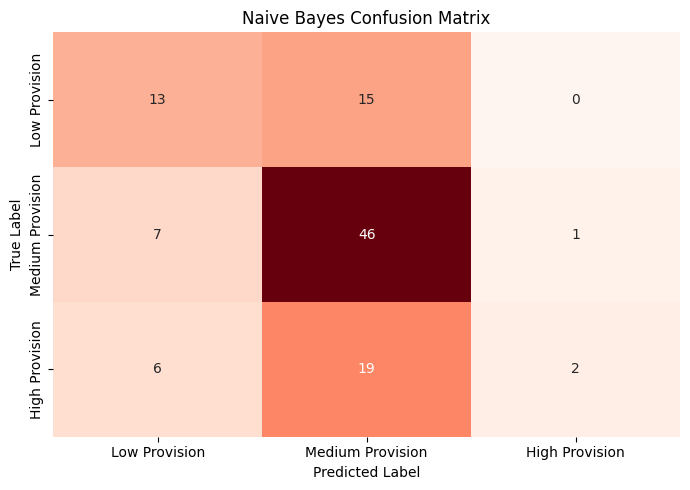

In [229]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, confusion_matrix

# 1. Instantiate the Gaussian Naive Bayes model
nb_model = GaussianNB()

# 2. Fit the model using the training data
nb_model.fit(X_train_scaled, y_train)

# 3. Generate predictions across the test partition
nb_preds = nb_model.predict(X_test_scaled)

# 4. Output the classification report
print("--- MODEL 4: GAUSSIAN NAIVE BAYES RESULTS ---")
print(classification_report(y_test, nb_preds, zero_division=0))

# 5. Visualize the Confusion Matrix using a Seaborn Heatmap
plt.figure(figsize=(7, 5))
classes = ['Low Provision', 'Medium Provision', 'High Provision']
cm_nb = confusion_matrix(y_test, nb_preds, labels=classes)

sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Reds', xticklabels=classes, yticklabels=classes, cbar=False)
plt.title("Naive Bayes Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

### Technical Evaluation: Probabilistic Independence Performance
* Correlated Feature Distortion: Gaussian Naive Bayes achieves 56% global accuracy but struggles significantly on the High Provision tier (0.07 recall). This underperformance demonstrates the model's core theoretical limitation: the class independence assumption. Because regional wealth and localized populations are naturally correlated metrics, Naive Bayes suffers from skewed class probabilities.

* Class Asymmetry: While the model functions well when establishing boundaries for the Low Provision class (0.46 recall), its probabilistic assumptions break down in the upper tail of the data distribution. This reinforces that a strict probabilistic model struggles with heavily overlapping, non-independent infrastructure datasets.

### 4.0 Strategic Model Interpretation and Recommendations

#### Model Selection Rationale
For regional infrastructure planning, a global accuracy score is an illusory metric. If stakeholders rely on the RBF SVM or kNN models, their high global accuracy ($51\%$ and $55\%$ respectively) masks a critical planning failure: a near-total blindness to High Provision regions (both scoring a critical 0.07 recall).

The Decision Tree Classifier (Model 2) is selected as the optimal deployment model for this infrastructure pipeline. It is the only classifier that successfully decouples the heavily overlapping socio-economic features, achieving a Macro F1-score of 0.51 and maintaining robust predictive power across the entire operational spectrum (0.61 recall for Low Provision and 0.30 recall for High Provision).

#### Real-World Resource Allocation Impact
* Mitigating Stranded Regions (False Highs): In infrastructure deployment, predicting an area has High Provision when it is actually Low results in funding being diverted away from vulnerable, under-served communities. The Decision Tree minimizes this risk by maintaining a high precision profile.

* Targeted Funding Efficiency: By utilizing the hierarchical, rule-based logic of the Decision Tree, regional planners can reliably flag 61% of all under-served local authorities and 30% of high-density infrastructure zones. This provides an empirical framework for allocating installation budgets where they will yield the highest social and economic return, moving beyond the limitations of standard linear or distance-voting models.